# 05 — Flux side-car (Phase 1: single denoising trajectory)

**This notebook is the Flux Phase-1 test bench.** The host line is a
synthetic, random-weight MMDiT shim (`ewm-flux-host` — the stand-in for
aarambh-vision-studio's rectified-flow sampler until its inference runtime
stabilizes); the side-car line is the in-process ewm-state-machine loop:
per-step S(t) → H(t-1), D/R/N, Boolean-ring window, warnings, and the
two-score evaluation. Everything runs in one `cargo run` per trajectory —
no torch, no model weights, no GPU.

The two scores are the generative-model counterpart of the Qwen bench
(docs/ASSIGNMENT_QWENDRIVE.md):

- **loop accuracy** — latent token restoration: the ordered materialization
  must hand the host back its own quantized encodings (positional and
  hash-level set; expected 1.0);
- **decode quality** — latent reconstruction: quantized ids are decoded back
  through the shared codebook (anchor + batch mean) and compared to the
  original latent (cosine / MSE). With a random codebook this is low by
  construction; once a real VAE exists it becomes the image-metric score.


In [1]:
# ── 0. Environment check (stdlib only) ────────────────────────────────────
# This notebook needs only numpy + matplotlib plus the ewm-flux-host binary.
# The `deepseek-ocr` conda env (the notebook-02 pattern) has both; no torch.
import sys

print("python:", sys.executable)
MISSING = []
for mod in ["numpy", "matplotlib"]:
    try:
        __import__(mod)
    except ImportError:
        MISSING.append(mod)
if MISSING:
    print("MISSING:", MISSING)
    print("recommended: Kernel -> Change Kernel -> Python (deepseek-ocr)")
    print("             (" + "/home/alexmy/.conda/envs/deepseek-ocr/bin/python" + ")")
    print("or install:  pip install " + " ".join(MISSING))
else:
    print("all dependencies present")


python: /home/alexmy/.conda/envs/deepseek-ocr/bin/python


all dependencies present


In [2]:
import os, json, subprocess
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
EWM_FLUX_BIN = os.path.join(EWM_SM, "target/debug/ewm-flux-host")
WORK = "/tmp/ewm_flux_sidecar"
os.makedirs(WORK, exist_ok=True)

# Build the side-car host adapter if it is not there yet.
if not os.path.exists(EWM_FLUX_BIN):
    print("building ewm-flux-host (first time) ...", flush=True)
    subprocess.run(["cargo", "build", "--quiet", "-p", "ewm-flux-host"],
                   cwd=EWM_SM, check=True)
    print("built", EWM_FLUX_BIN)
else:
    print("ewm-flux-host binary present:", EWM_FLUX_BIN)


def ewm_flux(*args):
    r = subprocess.run([EWM_FLUX_BIN, *args], capture_output=True, text=True, timeout=600)
    if r.returncode != 0:
        raise RuntimeError(f"ewm-flux-host failed: {r.stderr[-800:]}")
    return json.loads(r.stdout.strip())


print("ewm-state-machine:", EWM_SM)

report = ewm_flux()                 # synthetic trajectory, jump injected at step 16
clean  = ewm_flux("--no-disturb")   # the same trajectory, no jump

with open(f"{WORK}/flux_report.json", "w") as f:
    json.dump(report, f, indent=2)
print("report saved to", f"{WORK}/flux_report.json")
print("config:", json.dumps(report["config"]))
print("frames:", len(report["frames"]), "(denoising steps + the initial noise state)")


ewm-flux-host binary present: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-flux-host
ewm-state-machine: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine


report saved to /tmp/ewm_flux_sidecar/flux_report.json
config: {"seq_len": 256, "dim": 64, "steps": 28, "codebook": 4096, "seed": 42, "amp": 2.0, "disturbance": {"step": 16, "scale": 12.0, "patch": 32}, "ring_capacity": 64}
frames: 29 (denoising steps + the initial noise state)


---
## The two-score evaluation

Score 1 is the side-car's contract: the HLLSet round-trip must restore the
exact quantized token sequence (positional) and the exact token set
(hash-level — IICA guarantees every builder returns). Score 2 is the host
decoder's contract: how well the codebook inverse reconstructs the latent.


In [3]:
s = report["scores"]
print("Score 1 — loop accuracy (latent token restoration)")
print("  ordered positional :", round(s["loop_accuracy_mean"], 6), " (expected 1.0)")
print("  order exact        :", s["loop_order_exact"])
print("  hash-level set     : recall", round(s["loop_set_recall_mean"], 6),
      "| precision", round(s["loop_set_precision_mean"], 6), "(expected 1.0)")
print("  IICA set exact     :", s["loop_exact"])
print("Score 2 — decode quality (latent reconstruction, anchor + batch mean)")
print("  cosine mean        :", round(s["decode_cosine_mean"], 4))
print("  mse/channel mean   :", round(s["decode_mse_mean"], 4))
print()
print("With a random codebook decode quality is low by construction — the score")
print("is defined and measurable now, and a trained VAE lifts it later.")


Score 1 — loop accuracy (latent token restoration)
  ordered positional : 1.0  (expected 1.0)
  order exact        : True
  hash-level set     : recall 1.0 | precision 1.0 (expected 1.0)
  IICA set exact     : True
Score 2 — decode quality (latent reconstruction, anchor + batch mean)
  cosine mean        : 0.3228
  mse/channel mean   : 9.3704

With a random codebook decode quality is low by construction — the score
is defined and measurable now, and a trained VAE lifts it later.


---
## The trajectory — soft key, step lengths, residual, D/R/N

The ring basis changes as each step enters the window — unavoidable, since
the basis is the span of the context so far. A soft-key vector measured at
an earlier step therefore lives in an earlier coordinate system. The report
carries both views:

- `soft` / `step_len` — the **online** view, measured against the basis of
  that moment (what a live side-car would see);
- `soft_final` / `step_final` — the **consistent** view: every step
  re-projected onto the final ring basis. The side-car stores the basis
  frames themselves (not per-HLLSet BSS vectors), so any HLLSet can be
  projected into any historical frame on demand; a projection is
  sub-millisecond, so it is recomputed, not cached.

Projecting a *new* step into an *older* frame is a legitimate similarity
reading. Its error is the **spill**: `|S(t) \ cover(final)|` — the bits of
S(t) the frame cannot see (the part outside the union of its basis
elements), reported per step as `spill_final`.

Each step also carries `basis_change`: `true` when the push changed the ring
basis. A basis change is a **structural event** — the context re-indexed
itself — and is the second commit condition next to `new bits > 0`.

The heatmap below uses the consistent `soft_final` matrix, so all rows share
one coordinate system. The dashed red line marks the injected jump (step 16).


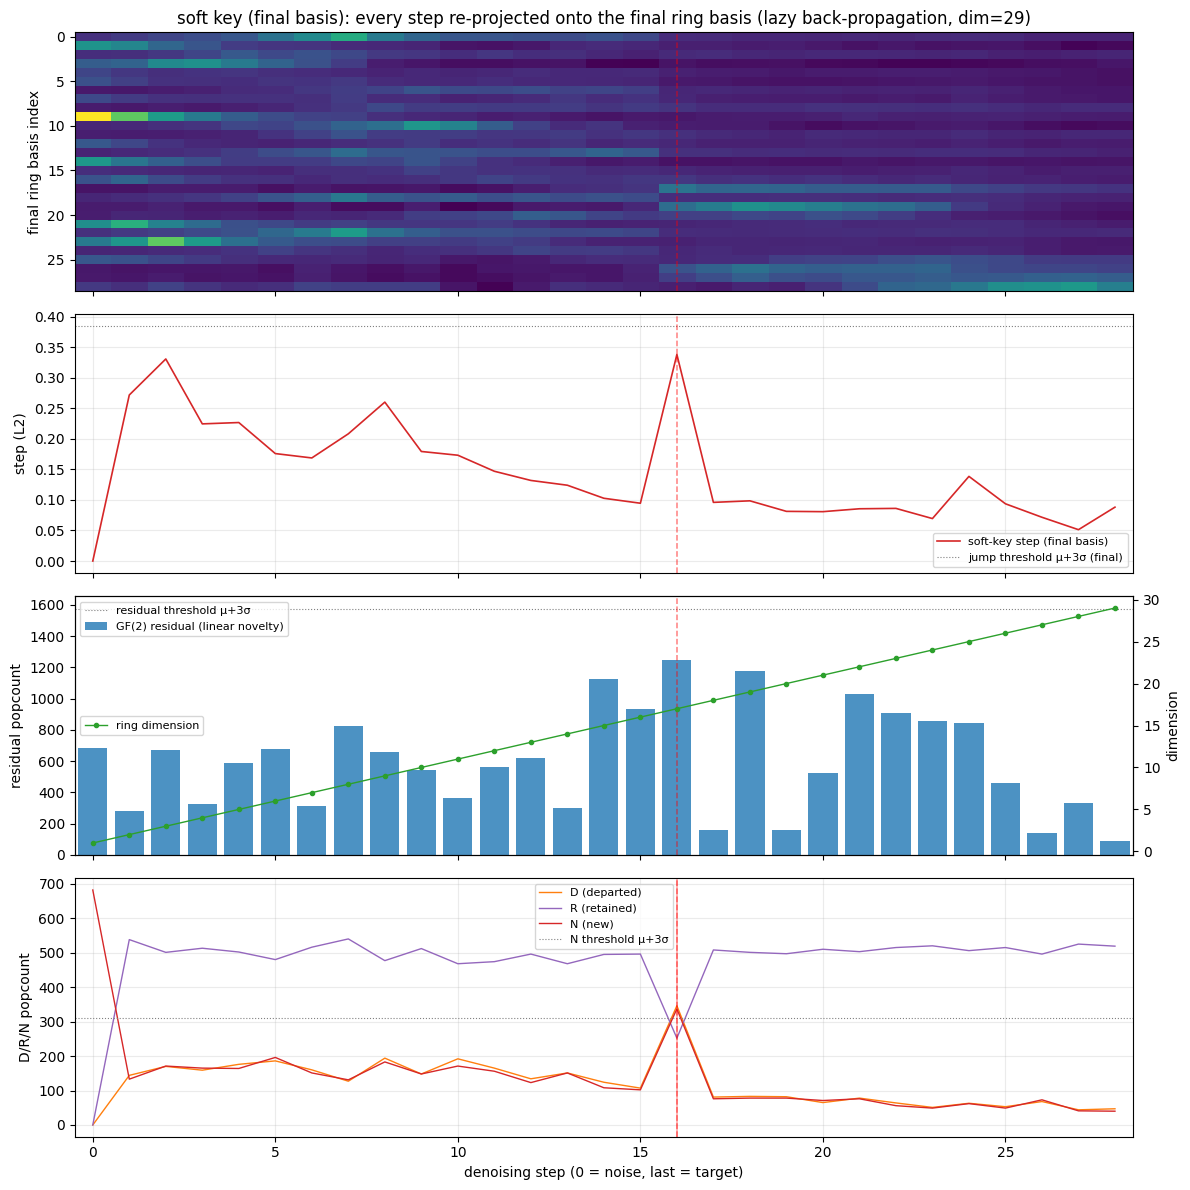

trajectory diagram saved to /tmp/ewm_flux_sidecar/flux_trajectory.png
warnings (online): {"jumps": [], "jump_threshold": 0.4125698162200613, "residual_spikes": [], "residual_threshold": 1576.3708107422308, "drn_shifts": [16], "drn_threshold": 309.7839536670564}
final-basis jumps : [] | threshold 0.3848
basis changes     : 29 | generations: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
structural events : 29 of 29 steps
final cover pop   : 2656 | mean spill: 0.0 | spill(last step in first frame): 429 bits


In [4]:
frames = report["frames"]
n = len(frames)
disturb_step = report["config"]["disturbance"]["step"] if report["config"]["disturbance"] else None

# Consistent soft-key matrix: every row re-projected onto the final basis
# (lazy back-propagation) — one shared coordinate system.
Wmat = np.array([f["soft_final"] for f in frames])
final_dim = report["final_projection"]["dimension"]
assert Wmat.shape == (n, final_dim)

step_final = np.array([f["step_final"] for f in frames], dtype=float)
residual = np.array([f["ring"]["residual"] for f in frames], dtype=float)
dim = np.array([f["ring"]["dimension"] for f in frames], dtype=int)
dpop = np.array([f["drn"]["d"] for f in frames], dtype=float)
rpop = np.array([f["drn"]["r"] for f in frames], dtype=float)
npop = np.array([f["drn"]["n"] for f in frames], dtype=float)

w = report["warnings"]
fp = report["final_projection"]
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].imshow(Wmat.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[0].set_ylabel("final ring basis index")
axes[0].set_title(f"soft key (final basis): every step re-projected onto the final ring basis "
                  f"(lazy back-propagation, dim={final_dim})")

axes[1].plot(range(n), step_final, color="#d62728", lw=1.2, label="soft-key step (final basis)")
axes[1].axhline(fp["jump_threshold"], color="gray", ls=":", lw=0.8, label="jump threshold μ+3σ (final)")
for j in fp["jumps"]:
    axes[1].axvline(j, color="red", alpha=0.35, lw=1.2)
axes[1].set_ylabel("step (L2)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

axes[2].bar(range(n), residual, color="tab:blue", alpha=0.8, label="GF(2) residual (linear novelty)")
axes[2].axhline(w["residual_threshold"], color="gray", ls=":", lw=0.8, label="residual threshold μ+3σ")
for j in w["residual_spikes"]:
    axes[2].axvline(j, color="red", alpha=0.35, lw=1.2)
ax2r = axes[2].twinx()
ax2r.plot(range(n), dim, color="tab:green", lw=1.0, marker=".", label="ring dimension")
ax2r.set_ylabel("dimension")
axes[2].set_ylabel("residual popcount")
axes[2].legend(fontsize=8, loc="upper left")
ax2r.legend(fontsize=8, loc="center left")

axes[3].plot(range(n), dpop, color="tab:orange", lw=1.0, label="D (departed)")
axes[3].plot(range(n), rpop, color="tab:purple", lw=1.0, label="R (retained)")
axes[3].plot(range(n), npop, color="tab:red", lw=1.0, label="N (new)")
axes[3].axhline(w["drn_threshold"], color="gray", ls=":", lw=0.8, label="N threshold μ+3σ")
for j in w["drn_shifts"]:
    axes[3].axvline(j, color="red", alpha=0.35, lw=1.2)
axes[3].set_ylabel("D/R/N popcount")
axes[3].set_xlabel("denoising step (0 = noise, last = target)")
axes[3].legend(fontsize=8)
axes[3].grid(alpha=0.25)

if disturb_step is not None:
    for ax in axes:
        ax.axvline(disturb_step, color="red", alpha=0.5, lw=1.1, ls="--")

plt.tight_layout()
plt.savefig(f"{WORK}/flux_trajectory.png", dpi=110)
plt.show()
print("trajectory diagram saved to", f"{WORK}/flux_trajectory.png")
print("warnings (online):", json.dumps(w))
print("final-basis jumps :", fp["jumps"], "| threshold", round(fp["jump_threshold"], 4))
print("basis changes     :", report["basis_changes"], "| generations:", report["basis_generations"])
print("structural events :", sum(1 for f in frames if f["basis_change"]), "of", n, "steps")
print("final cover pop   :", fp["cover_pop"], "| mean spill:", round(fp["spill_mean"], 3),
      "| spill(last step in first frame):", fp["spill_oldest"], "bits")


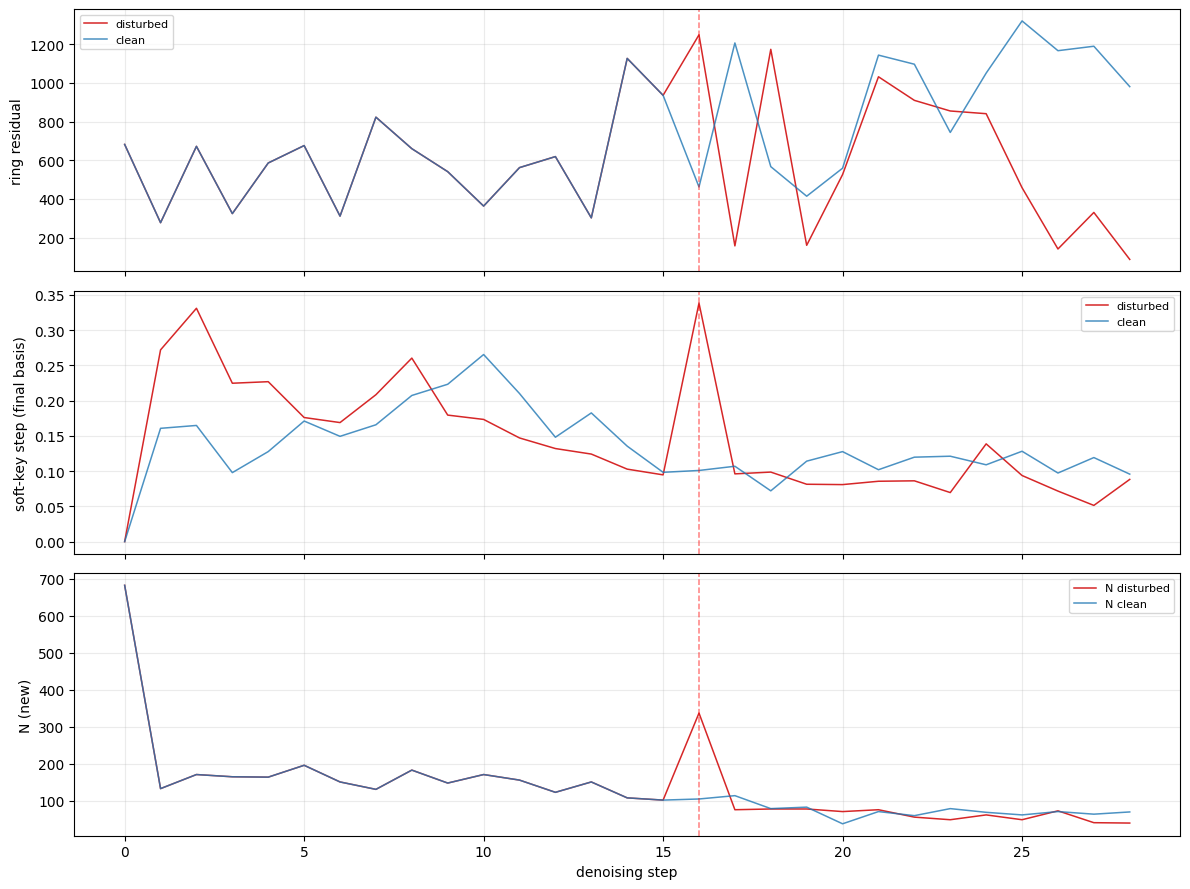

disturbed warnings: {"jumps": [], "jump_threshold": 0.4125698162200613, "residual_spikes": [], "residual_threshold": 1576.3708107422308, "drn_shifts": [16], "drn_threshold": 309.7839536670564}
clean warnings     : {"jumps": [], "jump_threshold": 0.3790621264345151, "residual_spikes": [], "residual_threshold": 1697.0429325796367, "drn_shifts": [], "drn_threshold": 247.49697887567487}
OK: the D/R/N shift warning fires exactly at the injected step 16


In [5]:
# ── The injected jump is the only difference between the two runs ──────────
cf = clean["frames"]
clean_res = np.array([f["ring"]["residual"] for f in cf], dtype=float)
clean_step_final = np.array([f["step_final"] for f in cf], dtype=float)
clean_n = np.array([f["drn"]["n"] for f in cf], dtype=float)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(range(n), residual, label="disturbed", color="#d62728", lw=1.1)
axes[0].plot(range(n), clean_res, label="clean", color="tab:blue", lw=1.1, alpha=0.8)
axes[0].set_ylabel("ring residual")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)

axes[1].plot(range(n), step_final, label="disturbed", color="#d62728", lw=1.1)
axes[1].plot(range(n), clean_step_final, label="clean", color="tab:blue", lw=1.1, alpha=0.8)
axes[1].set_ylabel("soft-key step (final basis)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25)

axes[2].plot(range(n), npop, label="N disturbed", color="#d62728", lw=1.1)
axes[2].plot(range(n), clean_n, label="N clean", color="tab:blue", lw=1.1, alpha=0.8)
axes[2].set_ylabel("N (new)")
axes[2].set_xlabel("denoising step")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.25)

if disturb_step is not None:
    for ax in axes:
        ax.axvline(disturb_step, color="red", alpha=0.5, lw=1.1, ls="--")

plt.tight_layout()
plt.savefig(f"{WORK}/flux_clean_vs_disturbed.png", dpi=110)
plt.show()

# Verify: the D/R/N shift warning lands exactly on the injected step.
print("disturbed warnings:", json.dumps(report["warnings"]))
print("clean warnings     :", json.dumps(clean["warnings"]))
if disturb_step is not None:
    assert report["warnings"]["drn_shifts"] == [disturb_step], \
        f"expected drn_shifts == [{disturb_step}], got {report['warnings']['drn_shifts']}"
    print(f"OK: the D/R/N shift warning fires exactly at the injected step {disturb_step}")


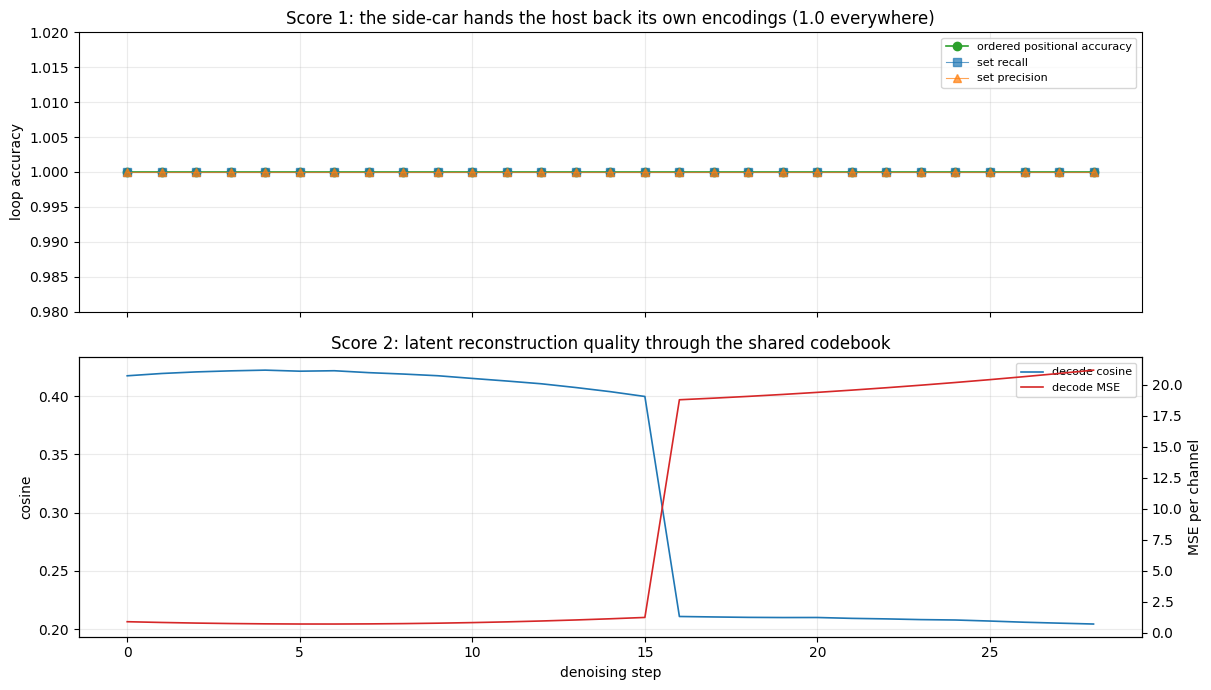

loop accuracy unique values: [1.]
decode cosine: min 0.204  max 0.422
decode mse   : min 0.722  max 21.162


In [6]:
# ── The two-score series over the trajectory ──────────────────────────────
acc = np.array([f["loop_accuracy"] for f in frames], dtype=float)
rec = np.array([f["loop_recall"] for f in frames], dtype=float)
pre = np.array([f["loop_precision"] for f in frames], dtype=float)
cos = np.array([f["decode"]["cosine"] for f in frames], dtype=float)
mse = np.array([f["decode"]["mse"] for f in frames], dtype=float)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(range(n), acc, "o-", color="tab:green", lw=1.2, label="ordered positional accuracy")
axes[0].plot(range(n), rec, "s-", color="tab:blue", lw=0.8, alpha=0.7, label="set recall")
axes[0].plot(range(n), pre, "^-", color="tab:orange", lw=0.8, alpha=0.7, label="set precision")
axes[0].set_ylim(0.98, 1.02)
axes[0].set_ylabel("loop accuracy")
axes[0].set_title("Score 1: the side-car hands the host back its own encodings (1.0 everywhere)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].plot(range(n), cos, color="tab:blue", lw=1.2, label="decode cosine")
axes[1].set_ylabel("cosine")
ax2 = axes[1].twinx()
ax2.plot(range(n), mse, color="tab:red", lw=1.2, label="decode MSE")
ax2.set_ylabel("MSE per channel")
axes[1].set_xlabel("denoising step")
axes[1].set_title("Score 2: latent reconstruction quality through the shared codebook")
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=8)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/flux_two_scores.png", dpi=110)
plt.show()
print("loop accuracy unique values:", np.unique(acc))
print("decode cosine: min", round(float(cos.min()), 3), " max", round(float(cos.max()), 3))
print("decode mse   : min", round(float(mse.min()), 3), " max", round(float(mse.max()), 3))


---
## Summary (Phase 1)

- **Synthetic random-weight MMDiT shim.** The host line is a deterministic
  rectified-flow ODE (`ewm-flux-host`), 256 latent tokens × 64 channels,
  28 denoising steps, seeded — no weights, no GPU.
- **Loop closed in-process.** Per step: the `SidecarProbe` quantizes the
  latent with the shared 4096-anchor codebook → `tid{n}` ids → HLLSet S(t);
  the side-car records H(t-1), D/R/N, the Boolean-ring window (soft/hard
  key, residual, rotation) and the warning flags.
- **Two-score evaluation.** Loop accuracy is 1.0 (ordered and hash-level)
  — the side-car hands the host back its own encodings exactly. Decode
  quality is measured as latent reconstruction cosine/MSE through the
  codebook inverse; it is low by construction for a random codebook and
  will become the image metric once a VAE exists.
- **Tangible warning.** The injected jump at step 16 fires the D/R/N shift
  warning exactly at step 16, and the clean run stays quiet.
- **Basis frames, not cached BSS vectors.** The ring basis changes as the run
  grows (unavoidable), so the side-car stores the basis frames themselves
  (one per basis change — itself a natural commit signal) and projects any
  HLLSet into any frame on demand. `soft_final` / `step_final` live in one
  coordinate system, and `spill_final = |S(t) \ cover(final)|` is the error
  of reading a step in the final frame.

Next steps: frozen-basis DFT of the soft-key trajectory (add a `--freeze`
to the flux host, mirroring `ewm-scene sidecar --freeze`), then port the
adapter crate into aarambh-vision-studio and drive it with the real
MMDiT sampler.
